In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [3]:
def load_text(path):
    with open(path, 'r', encoding='utf-8') as f:
        text = f.read()

    chars = sorted(list(set(text)))
    vocab_size = len(chars)

    stoi = {ch: i for i, ch in enumerate(chars)}
    itos = {i: ch for i, ch in enumerate(chars)}

    data = torch.tensor([stoi[c] for c in text], dtype=torch.long)

    return data, stoi, itos, vocab_size

In [4]:
def get_batch(data, batch_size, block_size):
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    return x, y

In [5]:
def create_causal_mask(T, device):
    mask = torch.triu(torch.ones(T, T), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask.to(device)

In [6]:
def self_attention(x, Wq, Wk, Wv, mask):
    B, T, C = x.shape

    Q = x @ Wq
    K = x @ Wk
    V = x @ Wv

    scores = Q @ K.transpose(-2, -1) / math.sqrt(C)
    scores = scores + mask

    weights = F.softmax(scores, dim=-1)

    out = weights @ V
    return out

In [7]:
def multi_head_attention(x, params, num_heads, mask):
    B, T, C = x.shape
    head_dim = C // num_heads

    outputs = []

    for h in range(num_heads):
        start = h * head_dim
        end = (h + 1) * head_dim

        x_h = x[:, :, start:end]

        out_h = self_attention(
            x_h,
            params['Wq'][h],
            params['Wk'][h],
            params['Wv'][h],
            mask
        )
        outputs.append(out_h)

    concat = torch.cat(outputs, dim=-1)
    out = concat @ params['Wo']

    return out

In [8]:
def feedforward(x, W1, W2):
    return (F.relu(x @ W1)) @ W2

In [9]:
def transformer_block(x, params, mask):
    # Attention
    attn_out = multi_head_attention(x, params['attn'], params['num_heads'], mask)
    x = x + attn_out
    x = params['ln1'](x)

    # Feedforward
    ff_out = feedforward(x, params['ff']['W1'], params['ff']['W2'])
    x = x + ff_out
    x = params['ln2'](x)

    return x

In [10]:
def forward(x, params):
    B, T = x.shape

    tok_emb = params['token_embedding'](x)
    pos_ids = torch.arange(T, device=x.device)
    pos_emb = params['position_embedding'](pos_ids)

    x = tok_emb + pos_emb
    mask = create_causal_mask(T, x.device)

    for block in params['blocks']:
        x = transformer_block(x, block, mask)

    x = params['final_ln'](x)
    logits = x @ params['output_linear']

    return logits

In [11]:
def compute_loss(logits, targets):
    B, T, V = logits.shape
    logits = logits.view(B*T, V)
    targets = targets.view(B*T)
    return F.cross_entropy(logits, targets)

In [24]:
def train(data, params, steps, batch_size, block_size, optimizer, loss_history=None, record_every=1, log_every=100):

    for step in range(steps):
        x, y = get_batch(data, batch_size, block_size)
        logits = forward(x, params)
        loss = compute_loss(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        if loss_history is not None and step % record_every == 0:
            loss_history.append(loss_value)

        if step % log_every == 0:
            print("step:", step, "loss:", loss_value)

In [13]:
def generate(start_tokens, params, max_new_tokens, block_size):
    x = start_tokens

    for _ in range(max_new_tokens):
        x_cond = x[:, -block_size:]

        logits = forward(x_cond, params)
        logits = logits[:, -1, :]

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        x = torch.cat((x, next_token), dim=1)

    return x

In [30]:
'''config'''
device = 'cpu'

batch_size = 32
block_size = 128
embed_dim = 128
num_heads = 4
num_layers = 4
ff_dim = 4 * embed_dim
steps = 7000
lr = 3e-4

# ====== LOAD DATA ======
data, stoi, itos, vocab_size = load_text('train.txt')

# ====== INIT PARAMS ======
def rand_param(*shape, scale):
    return nn.Parameter(torch.randn(*shape) * scale)

def init_params():
    params = {}

    params['token_embedding'] = nn.Embedding(vocab_size, embed_dim)
    params['position_embedding'] = nn.Embedding(block_size, embed_dim)

    blocks = []
    for _ in range(num_layers):
        block = {}

        attn = {}
        head_dim = embed_dim // num_heads

        attn['Wq'] = [rand_param(head_dim, head_dim, scale=1.0 / math.sqrt(embed_dim)) for _ in range(num_heads)]
        attn['Wk'] = [rand_param(head_dim, head_dim, scale=1.0 / math.sqrt(embed_dim)) for _ in range(num_heads)]
        attn['Wv'] = [rand_param(head_dim, head_dim, scale=1.0 / math.sqrt(embed_dim)) for _ in range(num_heads)]
        attn['Wo'] = rand_param(embed_dim, embed_dim, scale=1.0 / math.sqrt(embed_dim))

        block['attn'] = attn
        block['num_heads'] = num_heads

        block['ff'] = {
            'W1': rand_param(embed_dim, ff_dim, scale=1.0 / math.sqrt(embed_dim)),
            'W2': rand_param(ff_dim, embed_dim, scale=1.0 / math.sqrt(ff_dim))
        }

        block['ln1'] = nn.LayerNorm(embed_dim)
        block['ln2'] = nn.LayerNorm(embed_dim)

        blocks.append(block)

    params['blocks'] = blocks
    params['final_ln'] = nn.LayerNorm(embed_dim)
    params['output_linear'] = rand_param(embed_dim, vocab_size, scale=1.0 / math.sqrt(embed_dim))

    return params

params = init_params()

# ====== PARAM COLLECTION ======
def get_all_params(params):
    p = []

    p += list(params['token_embedding'].parameters())
    p += list(params['position_embedding'].parameters())

    for block in params['blocks']:
        for h in range(block['num_heads']):
            p.append(block['attn']['Wq'][h])
            p.append(block['attn']['Wk'][h])
            p.append(block['attn']['Wv'][h])

        p.append(block['attn']['Wo'])
        p.append(block['ff']['W1'])
        p.append(block['ff']['W2'])

        p += list(block['ln1'].parameters())
        p += list(block['ln2'].parameters())

    p += list(params['final_ln'].parameters())
    p.append(params['output_linear'])

    return p

train_loss_history = []

optimizer = torch.optim.Adam(get_all_params(params), lr=lr)

# call the training loop
train(data, params, steps, batch_size, block_size, optimizer, loss_history=train_loss_history)

# optional: save.. safe if if you want to continue training in later cells
torch.save(params, 'model.pth')

step: 0 loss: 4.785531997680664
step: 100 loss: 2.628314733505249
step: 200 loss: 2.5180861949920654
step: 300 loss: 2.481487512588501
step: 400 loss: 2.449002981185913
step: 500 loss: 2.421757936477661
step: 600 loss: 2.42225980758667
step: 700 loss: 2.3542888164520264
step: 800 loss: 2.2964794635772705
step: 900 loss: 2.279078960418701
step: 1000 loss: 2.2546496391296387
step: 1100 loss: 2.1636860370635986
step: 1200 loss: 2.1529178619384766
step: 1300 loss: 2.100050449371338
step: 1400 loss: 2.078472375869751
step: 1500 loss: 2.0642616748809814
step: 1600 loss: 2.030043601989746
step: 1700 loss: 2.0292305946350098
step: 1800 loss: 1.945609450340271
step: 1900 loss: 2.002248764038086
step: 2000 loss: 1.9242662191390991
step: 2100 loss: 1.876624584197998
step: 2200 loss: 1.8337717056274414
step: 2300 loss: 1.8657302856445312
step: 2400 loss: 1.8393669128417969
step: 2500 loss: 1.8492655754089355
step: 2600 loss: 1.7681782245635986
step: 2700 loss: 1.7595988512039185
step: 2800 loss: 1

In [31]:
import os

# loader
input_path = 'input.txt'
if not os.path.exists(input_path):
    input_path = 'train.txt'

data, stoi, itos, vocab_size = load_text(input_path)

if not os.path.exists('model.pth'):
    raise FileNotFoundError("model.pth not found. Run the training cell first.")

# Safe here because the checkpoint was created locally in this notebook.
params = torch.load('model.pth', map_location='cpu', weights_only=False)

# ====== GENERATE ======
start_char = 'H' if 'H' in stoi else next(iter(stoi))
start = torch.tensor([[stoi[start_char]]], dtype=torch.long)

generated = generate(start, params, max_new_tokens=300, block_size=128)

# decode
out = ''.join([itos[int(i)] for i in generated[0]])
print(out)

HASLENCE:
Is I with that him art.

BIONDELLO:
Can the therefore; but my hearty him, high nobless
Talk the satish his bend; in jurtiful wom
To not; for have you to thy womand's diam;
Assarrione this donter, at now hereth,
Lifttor: I'll are galeth art poor with our thy toook.
That shall ever, sad do in


In [32]:
import os

# extended training
extra_steps = 2000

if 'params' not in globals():
    if not os.path.exists('model.pth'):
        raise FileNotFoundError("model.pth not found. Run the training cell first.")
    # Safe here because the checkpoint was created locally in this notebook.
    params = torch.load('model.pth', map_location='cpu', weights_only=False)

if 'data' not in globals():
    data, stoi, itos, vocab_size = load_text('train.txt')

if 'extended_loss_history' not in globals():
    extended_loss_history = []

optimizer = torch.optim.Adam(get_all_params(params), lr=lr)
train(data, params, extra_steps, batch_size, block_size, optimizer, loss_history=extended_loss_history)

torch.save(params, 'model.pth')

step: 0 loss: 1.5314066410064697
step: 100 loss: 1.522834062576294
step: 200 loss: 1.5692886114120483
step: 300 loss: 1.6009474992752075
step: 400 loss: 1.564175009727478
step: 500 loss: 1.5077680349349976
step: 600 loss: 1.509709358215332
step: 700 loss: 1.5206974744796753
step: 800 loss: 1.5378307104110718
step: 900 loss: 1.5527377128601074
step: 1000 loss: 1.5519684553146362
step: 1100 loss: 1.5167330503463745
step: 1200 loss: 1.550302505493164
step: 1300 loss: 1.4997169971466064
step: 1400 loss: 1.4897195100784302
step: 1500 loss: 1.571807622909546
step: 1600 loss: 1.484135627746582
step: 1700 loss: 1.5144505500793457
step: 1800 loss: 1.4797947406768799
step: 1900 loss: 1.51874840259552


In [33]:
import os

# custom prompt
if 'params' not in globals():
    if not os.path.exists('model.pth'):
        raise FileNotFoundError("model.pth not found. Run the training cell first.")
    # Safe here because the checkpoint was created locally in this notebook.
    params = torch.load('model.pth', map_location='cpu', weights_only=False)

if 'data' not in globals() or 'stoi' not in globals():
    data, stoi, itos, vocab_size = load_text('train.txt')

prompt = input("Enter a prompt: ").strip()
if not prompt:
    prompt = "H"

if any(ch not in stoi for ch in prompt):
    if " " in stoi:
        prompt = "".join([ch if ch in stoi else " " for ch in prompt])
    else:
        prompt = "".join([ch for ch in prompt if ch in stoi])

if not prompt:
    raise ValueError("Prompt has no valid characters for the current vocabulary.")

start = torch.tensor([[stoi[ch] for ch in prompt]], dtype=torch.long)
generated = generate(start, params, max_new_tokens=300, block_size=block_size)

out = "".join([itos[int(i)] for i in generated[0]])
print(out)

if 'inference_loss_history' not in globals():
    inference_loss_history = []

infer_x, infer_y = get_batch(data, batch_size, block_size)
infer_logits = forward(infer_x, params)
infer_loss = compute_loss(infer_logits, infer_y)
inference_loss_history.append(infer_loss.item())
print("inference loss:", infer_loss.item())

hi wowan king'd.
Methink; by be younger a dayswors cunking,
My fathen I'll statingly.

Nill ELifne:
Having to please take the forgetn, blish the gods
The veryoners outacher'd countaly justing time,
And coursent silf a chasqued homicted
In much a dame: I concin of your know
her rearn than breast your city, m
inference loss: 1.4815595149993896


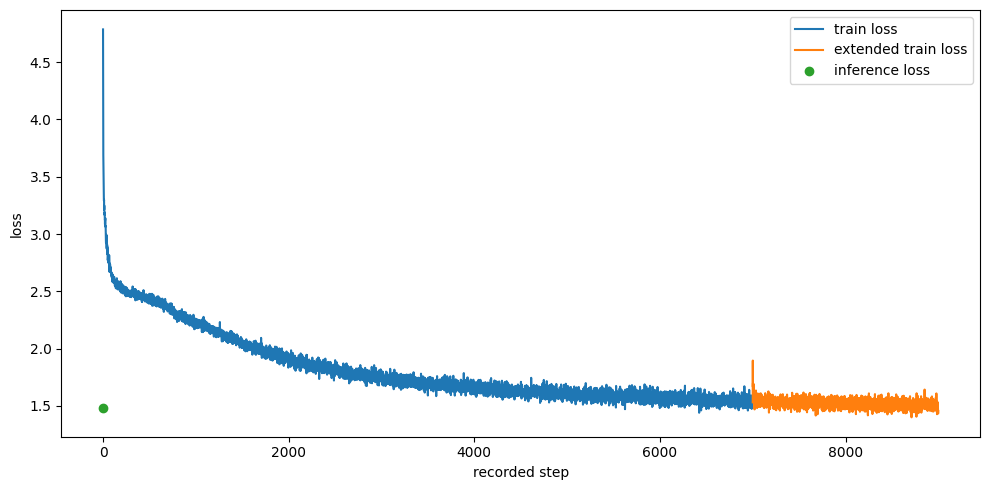

In [37]:
import matplotlib.pyplot as plt

has_any = False
plt.figure(figsize=(10, 5))

train_len = 0
if 'train_loss_history' in globals() and len(train_loss_history) > 0:
    plt.plot(train_loss_history, label='train loss')
    train_len = len(train_loss_history)
    has_any = True

if 'extended_loss_history' in globals() and len(extended_loss_history) > 0:
    x_ext = list(range(train_len, train_len + len(extended_loss_history)))
    plt.plot(x_ext, extended_loss_history, label='extended train loss')
    has_any = True

if 'inference_loss_history' in globals() and len(inference_loss_history) > 0:
    plt.plot(inference_loss_history, marker='o', linestyle='None', label='inference loss')
    has_any = True

if not has_any:
    print('No loss history found. Run training and inference first.')
else:
    plt.xlabel('recorded step')
    plt.ylabel('loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

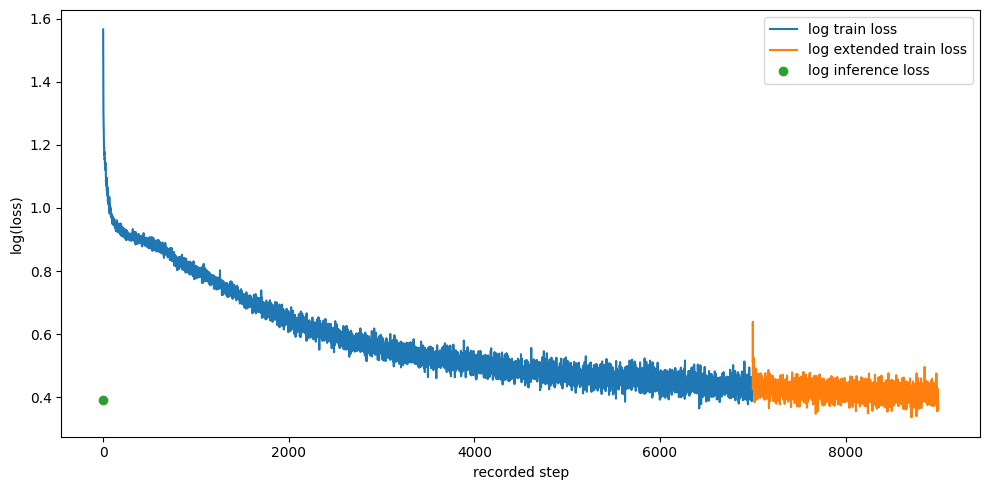

In [40]:
import matplotlib.pyplot as plt
import math

has_any = False
plt.figure(figsize=(10, 5))

train_len = 0
if 'train_loss_history' in globals() and len(train_loss_history) > 0:
    log_train = [math.log(v) for v in train_loss_history if v > 0]
    if log_train:
        plt.plot(log_train, label='log train loss')
        train_len = len(log_train)
        has_any = True

if 'extended_loss_history' in globals() and len(extended_loss_history) > 0:
    log_ext = [math.log(v) for v in extended_loss_history if v > 0]
    if log_ext:
        x_ext = list(range(train_len, train_len + len(log_ext)))
        plt.plot(x_ext, log_ext, label='log extended train loss')
        has_any = True

if 'inference_loss_history' in globals() and len(inference_loss_history) > 0:
    log_inf = [math.log(v) for v in inference_loss_history if v > 0]
    if log_inf:
        plt.plot(log_inf, marker='o', linestyle='None', label='log inference loss')
        has_any = True

if not has_any:
    print('No positive loss values found to plot in log scale.')
else:
    plt.xlabel('recorded step')
    plt.ylabel('log(loss)')
    plt.legend()
    plt.tight_layout()
    plt.show()